In [1]:
%load_ext autoreload
%autoreload 2

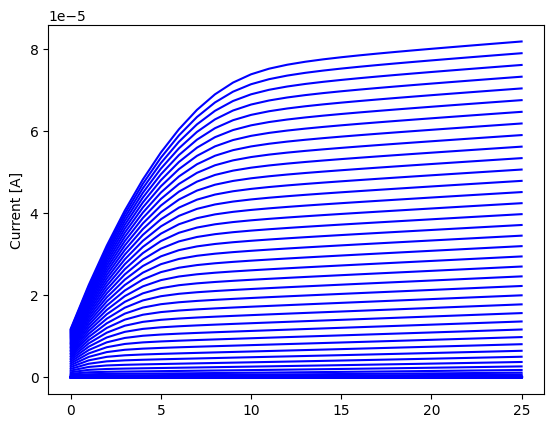

100%|██████████| 50000/50000 [53:39<00:00, 15.53it/s]  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import logging
from tqdm import tqdm
from src.get_first_device import get_first_device
from src.get_seperated_curves import get_seperated_curves
from src.plot_curves import plot_curves
from src.encoder import Encoder
from src.decoder import Decoder
from src.set_logger import set_logger
from src.get_reconstruction_loss import get_reconstruction_loss
from src.mlp import Mlp
from src.pretrain_latent_diffusion import pretrain_latent_diffusion
from src.visualize_0 import visualize_0
from src.get_20_devices import get_20_devices
from src.torch_dataset import TorchDataset

CSV_FILE = "nmos_130nm_gaussian_l_vth_rds_50_devs_into_subth.csv"
SEP = " "
DEVICE_DIM = 1378
CURRENT_COL = 3
VOLTAGE_0_DIM = 53
VOLTAGE_1_DIM = 26
LEARNING_RATE = 2e-4
EPOCHS = 50_000
LOGGING_FILE = "logs.log"
LOGGER_LEVEL = logging.INFO

dataframe = pd.read_csv(CSV_FILE, sep=SEP, header=None)
logger = set_logger(LOGGING_FILE, LOGGER_LEVEL)
torch_dataset = TorchDataset(
    dataframe,
    CURRENT_COL,
    DEVICE_DIM
)
train_loader = torch.utils.data.DataLoader(
    torch_dataset, batch_size=5
)

first_device_data = get_first_device(dataframe, DEVICE_DIM, CURRENT_COL)
separated_curves = get_seperated_curves(first_device_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
device = "cuda"

encoder = Encoder().to(device)
decoder = Decoder().to(device)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE
)

first_device_data_tensor = torch.tensor(first_device_data, dtype=torch.float32)
mse_loss = torch.nn.MSELoss()

devices_20_data = get_20_devices(dataframe, DEVICE_DIM, CURRENT_COL) 
devices_20_data_tensor = torch.tensor(devices_20_data, dtype=torch.float32)

loss_list = []
for epoch in tqdm(range(EPOCHS)):
    train_loader_iter = iter(train_loader)
    for batch_index, dev_data in enumerate(train_loader):
    # for dev in devices_20_data_tensor:
        device_data = dev_data.to(torch.float32)
        device_data = device_data.to(device)
        latent_data = encoder(device_data)
        output_data = decoder(latent_data)

        loss = get_reconstruction_loss(output_data, device_data)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss_list.append(loss.item())

    if epoch % 1000 == 0:
        plt.plot(loss_list[-1000:])
        plt.title(f"Epoch {epoch}")
        plt.savefig(f"loss_epoch{epoch}.png")
        plt.close()
    
    if epoch % 100 == 0:
        logger.info(f"EPOCH: {epoch} LOSS: {loss.item()}")

In [3]:
feature_0_list = []
feature_10_list = []

samples_list = []
for i in range(100):
    samples_list.append([])

for i in range(len(torch_dataset)):
    features_vector_np = torch_dataset[i]
    features_vector_tensor = torch.tensor(features_vector_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        latent_tensor = encoder(features_vector_tensor)
    latent_numpy =  latent_tensor.cpu().numpy()

    for index in range(len(latent_numpy)):
        samples_list[index].append(latent_numpy[index])

# plt.plot(feature_0_list)
# plt.show()
# plt.plot(feature_10_list)
var_list = []
mean_list = []

var_0_count = 0

for i in range(len(samples_list)):
    var_val = np.var(samples_list[i])
    var_list.append(var_val)
    mean_list.append(np.mean(samples_list[i]))

    if np.isclose(var_val, 0.0):
        var_0_count += 1

for i in range(len(samples_list)):
    print(var_list[i])

0.026302995
0.00042744388
0.02377337
0.032337822
0.028440043
0.0
0.0
0.03176991
0.0
0.023862414
0.0
0.0
0.025236174
0.0
0.0
0.0
0.0
0.026252346
0.02831131
0.03157192
0.027426584
0.030207371
0.0
0.026561482
0.028322903
0.030188737
0.03150373
0.025638191
0.00034505306
0.028718824
0.027194338
0.028543228
0.030531928
0.03242605
0.0
0.0
0.0
0.03283209
0.0
0.0
0.018159661
0.025991425
0.0
0.0
0.022250798
0.022879012
0.030462705
0.031348296
0.0317165
0.023030749
0.023121363
0.0240744
0.0
0.025372295
0.0
0.028363071
0.03152418
0.032778546
0.032889158
0.02523344
0.026331298
0.025901293
0.024336912
0.02142709
0.0
0.032390635
0.021270065
0.0
0.02853448
0.018632798
0.027841935
0.0004063905
0.0
0.0
0.0
0.0
0.0
0.029310184
0.026778216
0.00034972825
0.0
0.021484826
0.02945448
0.0
0.030577505
0.026906246
0.0
0.0
0.025378626
0.020241398
0.0
0.0005584981
0.0
0.0
0.0005887096
0.02718829
0.026340647
0.0
0.03596038
0.0


In [4]:
for i in range(len(samples_list)):
    print(mean_list[i])

0.13322438
0.003779493
0.086445816
0.13951255
0.11249113
0.0
0.0
0.13757858
0.0
0.08677039
0.0
0.0
0.10009315
0.0
0.0
0.0
0.0
0.10426797
0.1205556
0.13499145
0.106517985
0.12562901
0.0
0.115991935
0.114068165
0.13006932
0.13589306
0.11614817
0.0038355812
0.12776309
0.12568538
0.12942094
0.13924584
0.1371079
0.0
0.0
0.0
0.13725916
0.0
0.0
0.07702425
0.11737724
0.0
0.0
0.0998134
0.08349326
0.1387139
0.1318036
0.13706371
0.082217045
0.09560227
0.10588555
0.0
0.095625274
0.0
0.119555175
0.12123078
0.14214012
0.12477326
0.10206476
0.10747079
0.11422938
0.10505919
0.11362955
0.0
0.14270708
0.08226646
0.0
0.12512192
0.08842883
0.11999334
0.0028798752
0.0
0.0
0.0
0.0
0.0
0.12337362
0.10523365
0.0026715742
0.0
0.10501929
0.1279018
0.0
0.13304439
0.12367534
0.0
0.0
0.10920166
0.091868035
0.0
0.0033760807
0.0
0.0
0.0034661912
0.1230294
0.1136356
0.0
0.13523641
0.0


In [5]:
var_0_count

35

In [6]:
for i in range(len(samples_list)):
    print(f"VAR: {var_list[i]}  MEAN: {mean_list[i]}")

VAR: 0.026302995160222054  MEAN: 0.13322438299655914
VAR: 0.00042744388338178396  MEAN: 0.0037794930394738913
VAR: 0.023773370310664177  MEAN: 0.08644581586122513
VAR: 0.032337822020053864  MEAN: 0.1395125538110733
VAR: 0.028440043330192566  MEAN: 0.11249113082885742
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.03176990896463394  MEAN: 0.1375785768032074
VAR: 0.0  MEAN: 0.0
VAR: 0.023862414062023163  MEAN: 0.08677039295434952
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.02523617446422577  MEAN: 0.10009314864873886
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.0  MEAN: 0.0
VAR: 0.026252346113324165  MEAN: 0.10426796972751617
VAR: 0.028311310335993767  MEAN: 0.12055560201406479
VAR: 0.031571920961141586  MEAN: 0.13499145209789276
VAR: 0.02742658369243145  MEAN: 0.1065179854631424
VAR: 0.030207371339201927  MEAN: 0.1256290078163147
VAR: 0.0  MEAN: 0.0
VAR: 0.02656148187816143  MEAN: 0.11599193513393402
VAR: 0.02832290343940258  MEAN: 0.1140681654214859
VAR: 0.0301

tensor([1.8400e-11, 3.9857e-11, 8.6282e-11,  ..., 9.1552e-05, 9.4713e-05,
        9.7870e-05], device='cuda:0')


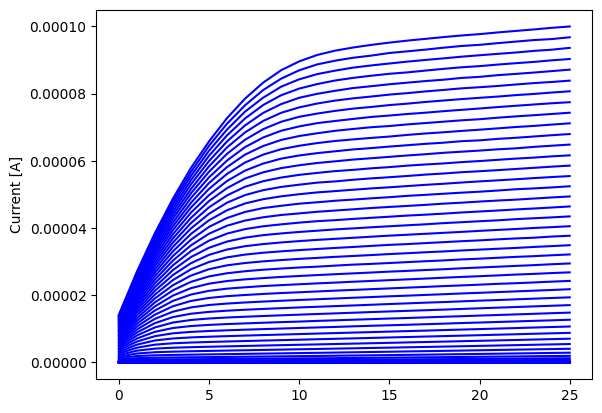

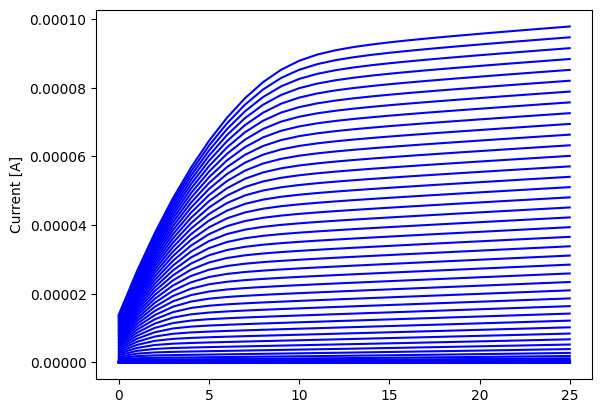

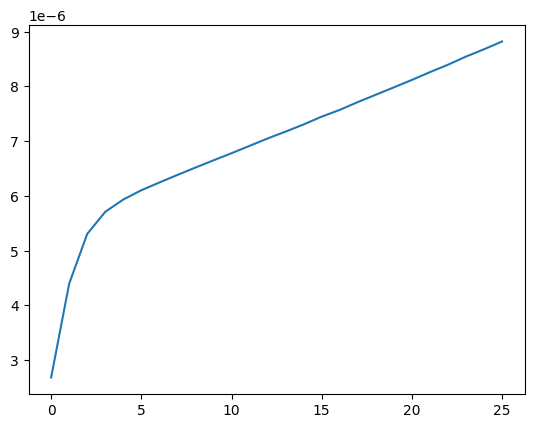

9.997807e-05


In [9]:
encoder.eval()
decoder.eval()

data_for_encoder = torch_dataset[2]
data_for_encoder = torch.tensor(data_for_encoder, dtype=torch.float32)
data_for_encoder = data_for_encoder.to(device)
# data_for_encoder = torch.zeros_like(data_for_encoder, dtype=torch.float32)
print(data_for_encoder)

with torch.no_grad():
    encoded_data = encoder(data_for_encoder)
    decoded_data = decoder(encoded_data)

decoded_data = decoded_data.cpu().numpy()
separated_curves = get_seperated_curves(decoded_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)
separated_curves_1 = get_seperated_curves(data_for_encoder.cpu().numpy(), VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves_1)

plt.plot(separated_curves[20])
plt.show()
print(np.max(decoded_data))

In [ ]:
TIMESTEPS = 40
EPOCHS = 300_000
mlp_model = Mlp(TIMESTEPS)
diffusion_optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=LEARNING_RATE
)
betas = (torch.sigmoid(torch.linspace(-18, 10, TIMESTEPS)) * (3e-1 - 1e-5) + 1e-5)
alphas = 1 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

pretrain_latent_diffusion(mlp_model, encoder, first_device_data_tensor, diffusion_optimizer, EPOCHS, betas, alphas, alphas_bar, TIMESTEPS, logger)

In [ ]:
out_tensor = visualize_0(
    first_device_data_tensor,
    alphas_bar,
    betas,
    alphas,
    TIMESTEPS,
    mlp_model,
    encoder,
    decoder
)

out_numpy_data = out_tensor.numpy()

separated_curves = get_seperated_curves(out_numpy_data, VOLTAGE_0_DIM, VOLTAGE_1_DIM)
plot_curves(separated_curves)